**Github** : https://github.com/OzgurYldrm/AI-ML-Course     
**Youtube** : https://www.youtube.com/@F%C3%BCt%C3%BCrist_AIntelligence

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F

# GPU

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# Data

In [2]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

# Test dataset
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

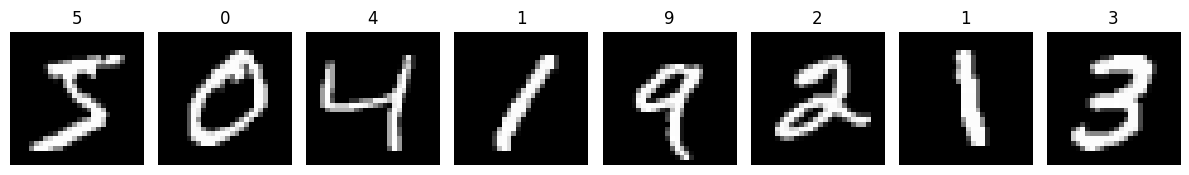

In [4]:
images = [train_dataset[i][0] for i in range(8)]
labels = [train_dataset[i][1] for i in range(8)]

plt.figure(figsize=(12,3))
for i in range(8):
    plt.subplot(1, 8, i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(str(labels[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

Normalize etmek için kullanacağımız değerleri alıyoruz

In [11]:
loader = DataLoader(train_dataset, batch_size=512, shuffle=False)

mean = 0.0
std = 0.0
total_images = 0

for images, _ in loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)

    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_images += batch_samples

mean /= total_images
std /= total_images

print(mean, std)

tensor([0.1307]) tensor([0.3015])


Create Dataset Dataloader

In [23]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=False,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=False,
    transform=transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

In [25]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Model

In [26]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1) # 1. Convolution layer: input 1 channel, output 16 channel, kernel 3x3
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1) # 2. Convolution layer: input 16 channel, output 32 channel, kernel 3x3
        self.fc1 = nn.Linear(32*7*7, 128) # Fully connected layer: 32*7*7 -> 12
        self.fc2 = nn.Linear(128, 10) # Output layer: 128 -> 10 classes
        self.pool = nn.MaxPool2d(2, 2) # Max pooling

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # [batch, 16, 14, 14]
        x = self.pool(F.relu(self.conv2(x)))  # [batch, 32, 7, 7]
        x = x.view(-1, 32*7*7)                # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


In [27]:
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training

In [28]:
for images, labels in train_loader:
        print(images.shape, labels.shape) # Batch_size, Channel, Height, Width
        break

torch.Size([64, 1, 28, 28]) torch.Size([64])


In [30]:
def evaluate(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [31]:
epochs = 5

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    val_acc = evaluate(val_loader)
    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1 | Loss: 145.1459 | Val Acc: 0.9790
Epoch 2 | Loss: 40.1255 | Val Acc: 0.9822
Epoch 3 | Loss: 27.4358 | Val Acc: 0.9848
Epoch 4 | Loss: 22.0113 | Val Acc: 0.9865
Epoch 5 | Loss: 15.4989 | Val Acc: 0.9848


# Test

In [32]:
evaluate(test_loader)

0.98475

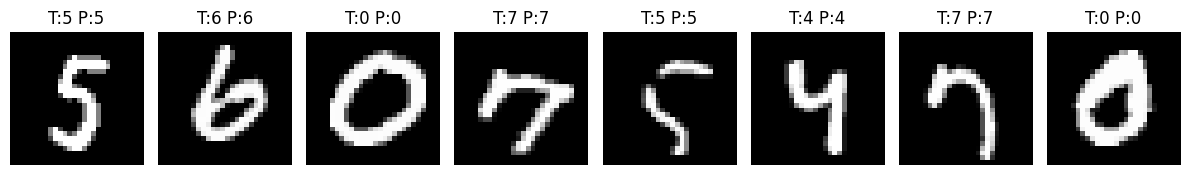

In [35]:
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1).cpu()
images = images.cpu()

plt.figure(figsize=(12,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"T:{labels[i]} P:{preds[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()